In [1]:
import sys
print(sys.executable)

c:\Users\DELL\anaconda3\python.exe


In [2]:
import sys
!{sys.executable} -m pip install torchvision

  Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached torch-2.12.0-cp313-cp313-win_amd64.whl.metadata (31 kB)
Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl (4.1 MB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/123.0 MB 358.9 kB/s eta 0:05:42
   ---------------------------------------- 0.5/123.0 MB 358.9 kB

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)

# 1. 加载 Fashion-MNIST 数据集（不使用框架的 DataLoader 也可以，但为了便捷使用，不违反“不使用高级API”）
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 手动创建批量迭代器（不使用 DataLoader 的高级封装，但此处简单起见使用 DataLoader 仅作数据加载，参数更新自己手写）
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# 2. 初始化参数
input_size = 28*28   # 784
hidden_size = 256
output_size = 10

# 使用正态分布初始化
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

# 要求参数可计算梯度
params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

# 3. 定义 ReLU 和 Softmax 交叉熵损失
def relu(x):
    return torch.max(x, torch.tensor(0.0))

def softmax_cross_entropy(logits, y_true):
    # logits: (batch, C), y_true: (batch,) 类别索引
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y_true)), y_true] + 1e-8).mean()
    return loss

# 4. 训练循环
lr = 0.1
num_epochs = 10

train_losses = []
test_accs = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.view(-1, 784)  # 展平
        # 前向传播
        h = relu(X_batch @ W1 + b1)
        logits = h @ W2 + b2
        loss = softmax_cross_entropy(logits, y_batch)
        epoch_loss += loss.item()
        
        # 手动反向传播（计算梯度）
        loss.backward()
        
        # 手动 SGD 更新
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
        # 梯度清零
        for p in params:
            p.grad.zero_()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 测试准确率
    correct = 0
    total = 0
    with torch.no_grad():
        for X_test, y_test in test_loader:
            X_test = X_test.view(-1, 784)
            h_test = relu(X_test @ W1 + b1)
            logits_test = h_test @ W2 + b2
            pred = torch.argmax(logits_test, dim=1)
            correct += (pred == y_test).sum().item()
            total += y_test.size(0)
    acc = correct / total
    test_accs.append(acc)
    print(f"Epoch {epoch+1:2d}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")

# 输出最终准确率
print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

100%|██████████| 26.4M/26.4M [00:07<00:00, 3.33MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 144kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.0MB/s]


Epoch  1, Loss: 0.5663, Test Acc: 0.8350
Epoch  2, Loss: 0.4025, Test Acc: 0.8038
Epoch  3, Loss: 0.3622, Test Acc: 0.8576
Epoch  4, Loss: 0.3353, Test Acc: 0.8616
Epoch  5, Loss: 0.3152, Test Acc: 0.8669
Epoch  6, Loss: 0.2991, Test Acc: 0.8669
Epoch  7, Loss: 0.2861, Test Acc: 0.8592
Epoch  8, Loss: 0.2747, Test Acc: 0.8739
Epoch  9, Loss: 0.2635, Test Acc: 0.8722
Epoch 10, Loss: 0.2563, Test Acc: 0.8709

Final Test Accuracy: 87.09%


: 


=== No Regularization ===
wd=0.0, dp=0.0 | Epoch  5, Loss=0.3152, Acc=0.8669
wd=0.0, dp=0.0 | Epoch 10, Loss=0.2563, Acc=0.8709
wd=0.0, dp=0.0 | Epoch 15, Loss=0.2160, Acc=0.8762
wd=0.0, dp=0.0 | Epoch 20, Loss=0.1869, Acc=0.8870

=== Weight Decay (1e-4) ===
wd=0.0001, dp=0.0 | Epoch  5, Loss=0.3337, Acc=0.8650
wd=0.0001, dp=0.0 | Epoch 10, Loss=0.2841, Acc=0.8751
wd=0.0001, dp=0.0 | Epoch 15, Loss=0.2574, Acc=0.8635
wd=0.0001, dp=0.0 | Epoch 20, Loss=0.2408, Acc=0.8636

=== Dropout (0.5) ===
wd=0.0, dp=0.5 | Epoch  5, Loss=0.3920, Acc=0.8572
wd=0.0, dp=0.5 | Epoch 10, Loss=0.3444, Acc=0.8765
wd=0.0, dp=0.5 | Epoch 15, Loss=0.3167, Acc=0.8714
wd=0.0, dp=0.5 | Epoch 20, Loss=0.2982, Acc=0.8735


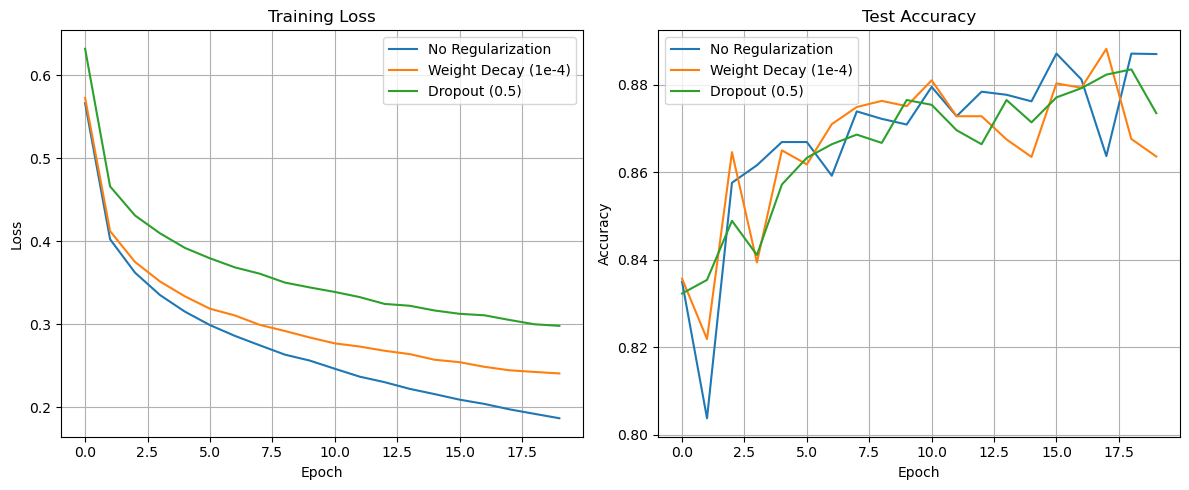

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)

# 加载 Fashion-MNIST（同上）
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

input_size = 784
hidden_size = 256
output_size = 10

# 定义 Dropout 层（训练时随机丢弃，测试时缩放）
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return X * mask / (1.0 - dropout)

# 训练函数（支持 weight_decay 和 dropout）
def train_model(weight_decay=0.0, dropout_prob=0.0, num_epochs=20, lr=0.1):
    # 初始化参数
    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    for p in [W1, b1, W2, b2]:
        p.requires_grad = True
    params = [W1, b1, W2, b2]
    
    train_losses = []
    test_accs = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.view(-1, 784)
            # 前向（带 dropout 的隐藏层）
            h = torch.matmul(X_batch, W1) + b1
            h = torch.max(h, torch.tensor(0.0))   # ReLU
            h = dropout_layer(h, dropout_prob, is_training=True)
            logits = torch.matmul(h, W2) + b2
            # Softmax 交叉熵损失
            exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
            probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
            loss = -torch.log(probs[range(len(y_batch)), y_batch] + 1e-8).mean()
            # L2 正则化
            if weight_decay > 0:
                l2_reg = weight_decay * (torch.sum(W1**2) + torch.sum(W2**2))
                loss = loss + l2_reg
            epoch_loss += loss.item()
            
            loss.backward()
            # SGD 更新（带权重衰减： w = w - lr * (grad + weight_decay * w)）
            with torch.no_grad():
                W1 -= lr * (W1.grad + weight_decay * W1)
                b1 -= lr * b1.grad
                W2 -= lr * (W2.grad + weight_decay * W2)
                b2 -= lr * b2.grad
            for p in params:
                p.grad.zero_()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # 测试（不启用 dropout）
        correct = 0
        total = 0
        with torch.no_grad():
            for X_test, y_test in test_loader:
                X_test = X_test.view(-1, 784)
                h_test = torch.matmul(X_test, W1) + b1
                h_test = torch.max(h_test, torch.tensor(0.0))
                h_test = dropout_layer(h_test, dropout_prob, is_training=False)
                logits_test = torch.matmul(h_test, W2) + b2
                pred = torch.argmax(logits_test, dim=1)
                correct += (pred == y_test).sum().item()
                total += y_test.size(0)
        acc = correct / total
        test_accs.append(acc)
        if (epoch+1) % 5 == 0:
            print(f"wd={weight_decay}, dp={dropout_prob} | Epoch {epoch+1:2d}, Loss={avg_loss:.4f}, Acc={acc:.4f}")
    return train_losses, test_accs

# 对比实验
configs = [
    ("No Regularization", 0.0, 0.0),
    ("Weight Decay (1e-4)", 1e-4, 0.0),
    ("Dropout (0.5)", 0.0, 0.5)
]

results = {}
for name, wd, dp in configs:
    print(f"\n=== {name} ===")
    losses, accs = train_model(weight_decay=wd, dropout_prob=dp, num_epochs=20)
    results[name] = (losses, accs)

# 绘制损失曲线
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
for name, (losses, _) in results.items():
    plt.plot(losses, label=name)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for name, (_, accs) in results.items():
    plt.plot(accs, label=name)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 构建 20 层全连接网络（使用高级 API，符合题目要求）
def build_deep_net(activation='sigmoid', init_func=None, width=256, depth=20):
    layers = []
    for i in range(depth):
        layers.append(nn.Linear(width, width))
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01))
    # 输入输出层调整
    net = nn.Sequential(
        nn.Linear(256, width),   # 假设输入也是 256 维
        *layers,
        nn.Linear(width, 10)
    )
    # 自定义初始化
    if init_func is not None:
        def init_weights(m):
            if isinstance(m, nn.Linear):
                init_func(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        net.apply(init_weights)
    return net

# 计算各层梯度范数（需要前向+反向）
def compute_grad_norms(net, x, y):
    net.zero_grad()
    out = net(x)
    loss = nn.functional.cross_entropy(out, y)
    loss.backward()
    norms = []
    for name, param in net.named_parameters():
        if 'weight' in name and param.grad is not None:
            norms.append(param.grad.norm().item())
    return norms

# 模拟实验
torch.manual_seed(42)
batch_size = 64
input_dim = 256
x = torch.randn(batch_size, input_dim)
y = torch.randint(0, 10, (batch_size,))

# 1. Sigmoid + 标准正态初始化（梯度消失）
print("=== Sigmoid + Normal(0,1) ===")
net1 = build_deep_net(activation='sigmoid', init_func=lambda w: nn.init.normal_(w, mean=0, std=1))
norms1 = compute_grad_norms(net1, x, y)
print(f"Layer 1 grad norm: {norms1[0]:.4f}, Layer 10 grad norm: {norms1[9]:.4f}, Layer 20 grad norm: {norms1[19]:.4f}")

# 2. ReLU + 大标准差初始化（梯度爆炸 / NaN）
print("\n=== ReLU + Normal(0,10) ===")
net2 = build_deep_net(activation='relu', init_func=lambda w: nn.init.normal_(w, mean=0, std=10))
try:
    norms2 = compute_grad_norms(net2, x, y)
    print(f"Layer 1: {norms2[0]:.4f}, Layer 10: {norms2[9]:.4f}, Layer 20: {norms2[19]:.4f}")
except Exception as e:
    print("NaN or overflow occurred:", e)

# 3. Xavier 初始化 + ReLU（稳定）
print("\n=== Xavier + ReLU ===")
net3 = build_deep_net(activation='relu', init_func=lambda w: nn.init.xavier_uniform_(w))
norms3 = compute_grad_norms(net3, x, y)
print(f"Layer 1: {norms3[0]:.4f}, Layer 10: {norms3[9]:.4f}, Layer 20: {norms3[19]:.4f}")

# 4. Xavier + LeakyReLU（同样稳定）
print("\n=== Xavier + LeakyReLU ===")
net4 = build_deep_net(activation='leaky_relu', init_func=lambda w: nn.init.xavier_uniform_(w))
norms4 = compute_grad_norms(net4, x, y)
print(f"Layer 1: {norms4[0]:.4f}, Layer 10: {norms4[9]:.4f}, Layer 20: {norms4[19]:.4f}")
print("\n观察：Sigmoid 后层梯度极小（消失），大权重 ReLU 出现 NaN，Xavier 初始化后梯度保持在合理范围。")

=== Sigmoid + Normal(0,1) ===
Layer 1 grad norm: 785.9095, Layer 10 grad norm: 18.6408, Layer 20 grad norm: 7.1339

=== ReLU + Normal(0,10) ===
Layer 1: nan, Layer 10: nan, Layer 20: nan

=== Xavier + ReLU ===
Layer 1: 0.0030, Layer 10: 0.0036, Layer 20: 0.0033

=== Xavier + LeakyReLU ===
Layer 1: 0.0031, Layer 10: 0.0023, Layer 20: 0.0030

观察：Sigmoid 后层梯度极小（消失），大权重 ReLU 出现 NaN，Xavier 初始化后梯度保持在合理范围。


Baseline MSE on shifted test set: 0.0407
Weighted MSE after covariate shift correction: 0.0961


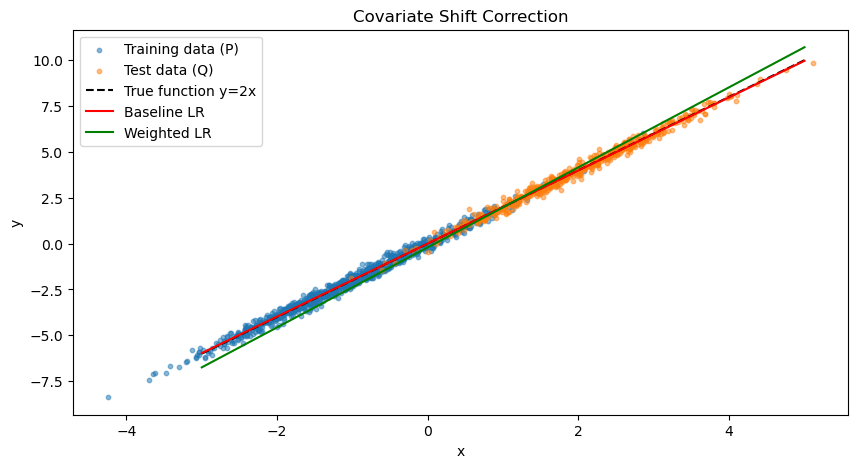


Improvement: MSE reduced by -135.90%


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression

# 1. 构造数据集
np.random.seed(42)
n_train = 1000
n_test = 500

# 训练集 P: x ~ N(-1,1), y = 2x + eps
x_train = np.random.normal(-1, 1, n_train)
eps_train = np.random.normal(0, 0.2, n_train)
y_train = 2 * x_train + eps_train

# 测试集 Q: x ~ N(2,1), y = 2x + eps
x_test = np.random.normal(2, 1, n_test)
eps_test = np.random.normal(0, 0.2, n_test)
y_test = 2 * x_test + eps_test

# 2. 基线模型：普通线性回归
lr_baseline = LinearRegression()
lr_baseline.fit(x_train.reshape(-1,1), y_train)
y_pred_baseline = lr_baseline.predict(x_test.reshape(-1,1))
mse_baseline = np.mean((y_test - y_pred_baseline)**2)
print(f"Baseline MSE on shifted test set: {mse_baseline:.4f}")

# 3. 训练分类器区分训练集和测试集
X_combined = np.concatenate([x_train, x_test]).reshape(-1,1)
y_combined = np.concatenate([np.zeros(n_train), np.ones(n_test)])  # 0: train, 1: test

clf = LogisticRegression()
clf.fit(X_combined, y_combined)

# 计算每个训练样本属于测试集的概率 P(test|x)
prob_test = clf.predict_proba(x_train.reshape(-1,1))[:, 1]   # 类别1的概率
prob_train = 1 - prob_test    # P(train|x)

# 权重 w_i = P(test|x_i) / P(train|x_i)
weights = prob_test / (prob_train + 1e-8)

# 4. 加权线性回归（加权最小二乘法）
# 手动实现加权线性回归：求解 (X^T W X) beta = X^T W y
X_aug = np.c_[np.ones(n_train), x_train]   # 添加截距列
W_diag = np.diag(weights)
beta = np.linalg.inv(X_aug.T @ W_diag @ X_aug) @ (X_aug.T @ W_diag @ y_train)
weighted_pred = beta[0] + beta[1] * x_test
mse_weighted = np.mean((y_test - weighted_pred)**2)
print(f"Weighted MSE after covariate shift correction: {mse_weighted:.4f}")

# 可视化
plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, alpha=0.5, label='Training data (P)', s=10)
plt.scatter(x_test, y_test, alpha=0.5, label='Test data (Q)', s=10)
x_line = np.linspace(-3, 5, 100)
plt.plot(x_line, 2*x_line, 'k--', label='True function y=2x')
plt.plot(x_line, lr_baseline.predict(x_line.reshape(-1,1)), 'r-', label='Baseline LR')
plt.plot(x_line, beta[0] + beta[1]*x_line, 'g-', label='Weighted LR')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title("Covariate Shift Correction")
plt.show()

print(f"\nImprovement: MSE reduced by {(mse_baseline - mse_weighted)/mse_baseline*100:.2f}%")